In [88]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score ,classification_report
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler


In [89]:
df = pd.read_csv("../data/Titanic-Dataset.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [90]:
df.shape

(891, 12)

In [91]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [92]:
df.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [93]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [94]:
df['Age'] = df['Age'].fillna(df.groupby("Sex")["Age"].transform("mean"))

df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

df.drop(["PassengerId","Cabin","Name","Ticket"],axis=1 , inplace=True)

In [95]:
df.isna().sum()

Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64

In [96]:
df.duplicated().sum()

np.int64(111)

In [97]:
df.drop_duplicates(inplace=True)

In [98]:
df.shape

(780, 8)

In [99]:
x = df.drop("Survived" , axis = 1)
y = df["Survived"]

In [100]:
num_cols = x.select_dtypes(include=["int64", "float64"]).columns
cat_cols = x.select_dtypes(include=["object"]).columns

In [101]:
x.info()

<class 'pandas.core.frame.DataFrame'>
Index: 780 entries, 0 to 890
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Pclass    780 non-null    int64  
 1   Sex       780 non-null    object 
 2   Age       780 non-null    float64
 3   SibSp     780 non-null    int64  
 4   Parch     780 non-null    int64  
 5   Fare      780 non-null    float64
 6   Embarked  780 non-null    object 
dtypes: float64(2), int64(3), object(2)
memory usage: 48.8+ KB


In [102]:
for col in cat_cols:
   encoder = LabelEncoder()
   x[col] = encoder.fit_transform(x[col])

In [103]:
x.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,3,1,22.0,1,0,7.2500,2
1,1,0,38.0,1,0,71.2833,0
2,3,0,26.0,0,0,7.9250,2
3,1,0,35.0,1,0,53.1000,2
4,3,1,35.0,0,0,8.0500,2


In [104]:
y.value_counts()

Survived
0    458
1    322
Name: count, dtype: int64

<Axes: xlabel='Fare', ylabel='Count'>

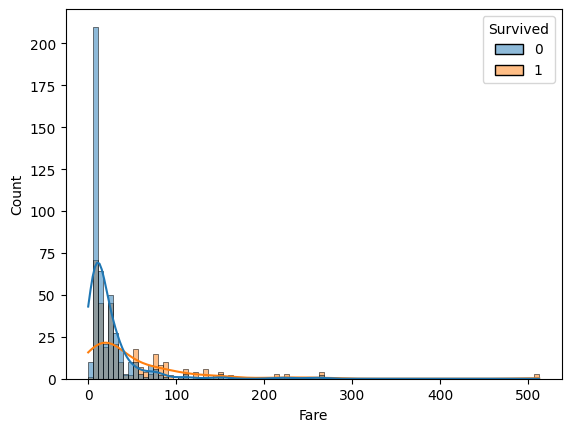

In [105]:
sns.histplot(data=df, x="Fare", hue="Survived", kde=True)


<Axes: xlabel='Age', ylabel='Count'>

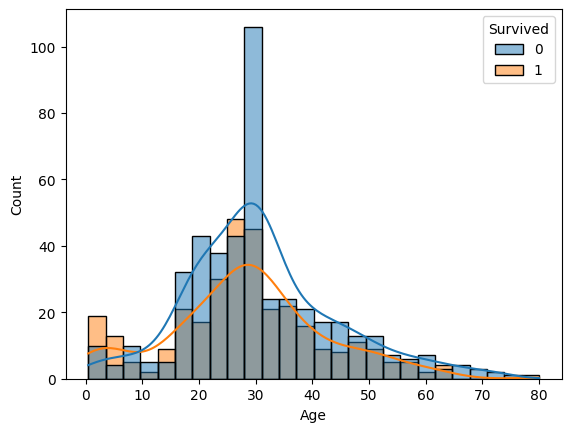

In [106]:
sns.histplot(data=df, x="Age", hue="Survived", kde=True)

In [107]:
x_train , x_test , y_train , y_test =train_test_split(x,y , test_size=0.2 , random_state=60)

In [108]:
scaler = StandardScaler()
x_train[num_cols] = scaler.fit_transform(x_train[num_cols])
x_test[num_cols] = scaler.transform(x_test[num_cols])

## Naive Bayes

In [109]:
model = GaussianNB(var_smoothing=1e-9 )
model.fit(x_train , y_train)

,priors,None
,var_smoothing,1e-09


In [110]:
y_train_pred = model.predict(x_train)
print("Accuracy:", accuracy_score(y_train, y_train_pred))


Accuracy: 0.7676282051282052


In [111]:
y_pred = model.predict(x_test)
print("Accuracy:", accuracy_score(y_test , y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.8076923076923077
              precision    recall  f1-score   support

           0       0.82      0.85      0.83        88
           1       0.80      0.75      0.77        68

    accuracy                           0.81       156
   macro avg       0.81      0.80      0.80       156
weighted avg       0.81      0.81      0.81       156



## SVM

##### Linear Kernel

In [112]:
svm_linear = SVC(kernel='linear',C=1.0,random_state=42)
svm_linear.fit(x_train, y_train)

,C,1.0
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [113]:
y_train_pred = svm_linear.predict(x_train)
print("Accuracy:", accuracy_score(y_train, y_train_pred))


Accuracy: 0.7596153846153846


In [114]:
y_pred_linear= svm_linear.predict(x_test)
print("Accuracy:", accuracy_score(y_test, y_pred_linear))
print(classification_report(y_test, y_pred_linear))



Accuracy: 0.7948717948717948
              precision    recall  f1-score   support

           0       0.80      0.85      0.82        88
           1       0.79      0.72      0.75        68

    accuracy                           0.79       156
   macro avg       0.79      0.79      0.79       156
weighted avg       0.79      0.79      0.79       156



##### RBF Kernel

In [115]:
svm_rbf = SVC(kernel='rbf', gamma="scale",C=1.0,random_state=42)
svm_rbf.fit(x_train, y_train)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [116]:
y_train_pred = svm_rbf.predict(x_train)
print("Accuracy:", accuracy_score(y_train, y_train_pred))


Accuracy: 0.8125


In [117]:
y_pred_rbf = svm_rbf.predict(x_test)
print("Accuracy:", accuracy_score(y_test, y_pred_rbf))
print(classification_report(y_test, y_pred_rbf))



Accuracy: 0.8205128205128205
              precision    recall  f1-score   support

           0       0.81      0.90      0.85        88
           1       0.84      0.72      0.78        68

    accuracy                           0.82       156
   macro avg       0.83      0.81      0.81       156
weighted avg       0.82      0.82      0.82       156



# Decision Tree

In [118]:
DT = DecisionTreeClassifier(criterion = 'log_loss',max_depth=5) 
DT.fit(x_train,y_train)

,criterion,'log_loss'
,splitter,'best'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [119]:
y_train_pred = DT.predict(x_train)
print("Accuracy:", accuracy_score(y_train, y_train_pred))


Accuracy: 0.8381410256410257


In [120]:
y_pred_dt = DT.predict(x_test)
print("Accuracy:",accuracy_score(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))

Accuracy: 0.8269230769230769
              precision    recall  f1-score   support

           0       0.80      0.93      0.86        88
           1       0.89      0.69      0.78        68

    accuracy                           0.83       156
   macro avg       0.84      0.81      0.82       156
weighted avg       0.84      0.83      0.82       156



# Logistic Regression

In [121]:
model = LogisticRegression(class_weight="balanced", random_state=42)

model.fit(x_train, y_train)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,42
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [122]:
y_train_pred = model.predict(x_train)
print("Accuracy:", accuracy_score(y_train, y_train_pred))


Accuracy: 0.7628205128205128


In [123]:
y_pred_log = model.predict(x_test)

print("Accuracy:", accuracy_score(y_test, y_pred_log))
print(classification_report(y_test, y_pred_log))

Accuracy: 0.8076923076923077
              precision    recall  f1-score   support

           0       0.85      0.80      0.82        88
           1       0.76      0.82      0.79        68

    accuracy                           0.81       156
   macro avg       0.81      0.81      0.81       156
weighted avg       0.81      0.81      0.81       156



#### It appers that Logistic Regression have the highest accuracy & overall values .